In [1]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

C:\Users\rohit\AppData\Local\Temp\ipykernel_14796\1860997399.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
load_dotenv()

True

In [3]:
# llm = ChatOpenAI()

In [4]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)

In [8]:
loader = PyPDFLoader("Activ_One_MAX_Policy_Wording_5c16bfaba5.pdf")
docs = loader.load()

In [9]:
docs

[Document(metadata={'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'Activ_One_MAX_Policy_Wording_5c16bfaba5.pdf', 'total_pages': 55, 'page': 0, 'page_label': '1'}, page_content="This Policy is a contract of insurance issued by ADITYA BIRLA HEALTH INSURANCE CO. LIMITED. (hereina/fter called the ‘We / Our / Us / Insurer / \nCompany’) to the proposer mentioned in the Policy Schedule (hereina/fter called the ‘You / Your / Policyholder’) to cover the person(s) named in the Policy \nSchedule (hereina/fter called the ‘Insured Person/s). The Policy has been issued on the basis of the Disclosure to Information Norm, including the information \nprovided by You in respect of the Insured Persons in the Proposal Form and on the statements and declaration provided by the Policyholder in the Proposal \nForm as well as in any welcome or other tele-veriﬁcation calls with the Company’s authorized person and is subject to receipt of the requisite premium in \nrespect of the Insure

In [10]:
len(docs)

55

In [11]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [12]:
len(chunks)

355

In [13]:
# embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
# vector_store = FAISS.from_documents(chunks, embeddings)

In [15]:
# embeddings = GoogleGenerativeAIEmbeddings(
#     model="gemini-embedding-001"
# )
# vector_store = FAISS.from_documents(chunks, embeddings)
# vector_store.save_local("faiss_index")

In [16]:
import time

from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

# Initialize Gemini Embeddings
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)

BATCH_SIZE = 50      # Reduce if you still hit rate limits
WAIT_TIME = 12       # Seconds between batches

vector_store = None

for i in range(0, len(chunks), BATCH_SIZE):
    batch = chunks[i:i + BATCH_SIZE]

    while True:
        try:
            if vector_store is None:
                vector_store = FAISS.from_documents(batch, embeddings)
            else:
                vector_store.add_documents(batch)

            print(f"Processed {min(i + BATCH_SIZE, len(chunks))}/{len(chunks)} chunks")

            # Wait before sending the next batch
            time.sleep(WAIT_TIME)
            break

        except Exception as e:
            error = str(e)

            # Handle Gemini rate limit
            if "RESOURCE_EXHAUSTED" in error or "429" in error:
                print("Rate limit exceeded. Waiting 15 seconds before retrying...")
                time.sleep(15)
            else:
                raise e

# Save FAISS index
vector_store.save_local("faiss_index")

print("FAISS index saved successfully.")

Processed 50/355 chunks
Processed 100/355 chunks
Rate limit exceeded. Waiting 15 seconds before retrying...
Rate limit exceeded. Waiting 15 seconds before retrying...
Processed 150/355 chunks
Processed 200/355 chunks
Rate limit exceeded. Waiting 15 seconds before retrying...
Rate limit exceeded. Waiting 15 seconds before retrying...
Processed 250/355 chunks
Processed 300/355 chunks
Rate limit exceeded. Waiting 15 seconds before retrying...
Rate limit exceeded. Waiting 15 seconds before retrying...
Processed 350/355 chunks
Processed 355/355 chunks
FAISS index saved successfully.


In [17]:
vector_store

In [18]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [19]:
ans = retriever.invoke("What is the policy about?")
ans

[Document(id='8a5b4062-f71d-4001-a114-0858a793e5d2', metadata={'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'Activ_One_MAX_Policy_Wording_5c16bfaba5.pdf', 'total_pages': 55, 'page': 24, 'page_label': '25'}, page_content='Any changes to the Policy can only be made in \nProduct Name: Activ One, Product UIN: ADIHLIP24097V012324 \nwriting and signed by us. Only we\ncan change or modify this Policy\nchange or vary this Policy.'),
 Document(id='8a5305fd-76c8-48ea-8889-384e43fb2f1d', metadata={'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'Activ_One_MAX_Policy_Wording_5c16bfaba5.pdf', 'total_pages': 55, 'page': 0, 'page_label': '1'}, page_content='This Policy is a contract of insurance issued by ADITYA BIRLA HEALTH INSURANCE CO. LIMITED. (hereina/fter called the ‘We / Our / Us / Insurer / \nCompany’) to the proposer mentioned in the Policy Schedule (hereina/fter called the ‘You / Your / Policyholder’) to cover the person(s) named in the Polic

In [21]:
@tool
def rag_tool(query: str) -> str:
    """
    Retrieve relevant information from the PDF document.

    Use this tool when the user asks factual or conceptual questions
    that may be answered using the stored PDF documents.

    Args:
        query: The question or search query used to retrieve PDF content.
    """

    documents = retriever.invoke(query)

    if not documents:
        return "No relevant information was found in the PDF."

    formatted_documents = []

    for index, document in enumerate(documents, start=1):
        source = document.metadata.get("source", "Unknown source")
        page = document.metadata.get("page", "Unknown page")

        formatted_documents.append(
            f"Document {index}\n"
            f"Source: {source}\n"
            f"Page: {page}\n"
            f"Content: {document.page_content}"
        )

    return "\n\n".join(formatted_documents)

In [22]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [23]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [24]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

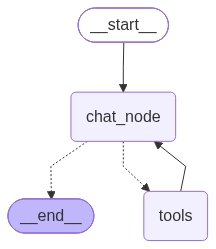

In [25]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")  
chatbot = graph.compile()

chatbot

In [27]:
# Regular chat
result = chatbot.invoke({"messages": [HumanMessage(content="What are diseases considered under this policy?")]})

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'This policy considers coverage for the following diseases and conditions:\n\n*   **Meningitis infection** (specifically, permanent objective neurological deficit present at least 3 months after diagnosis).\n*   **Illnesses, incapacitating disablement or death** caused by **Biological Attack or Weapons** (emission, discharge, dispersal, release or escape of pathogenic micro-organisms and/or biologically produced toxins).\n*   **Cancer Treatment** (primary treatment of a malignant tumor).\n*   **Bone Marrow Transplantation (BMT)** or **Peripheral Blood Stem Cell Transplantation (PBSCT)**.\n*   **Pre-existing diseases** (subject to declaration at the time of application and acceptance by the Insurer, and a specified waiting period).\n*   **Specified diseases/procedures** (subject to a 24-month waiting period of continuous coverage, unless due to an accident).\n*   **Chronic conditions listed at section C.13.8.4** (covered from Day 1 if found during pre-policy me

In [28]:
# Regular chat
result = chatbot.invoke({"messages": [HumanMessage(content="Using the pdf notes, explain about the health inurance i need to consider before taking the policy")]})

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Based on the PDF notes, here are the key health insurance considerations you should make before taking a policy:\n\n1.  **Continuous Coverage and Migration:** If you are already covered under an existing health insurance policy, especially with an Indian General/Health insurer, you have the option to migrate your policy. This allows you to potentially retain accrued benefits like waiting periods and moratoriums, as per IRDAI norms. You typically need to apply for migration 30 to 60 days before your policy renewal date. This also applies if you switch to other health insurance plans offered by the same company.\n2.  **Disclosure of Information:** It is critical to be truthful and disclose all material facts when purchasing the policy. Any misrepresentation, misdescription, or non-disclosure of important information can lead to the policy being voided and all paid premiums being forfeited by the company.\n3.  **Multiple Policies:** If you have more than one hea

In [29]:
print(result["messages"][-1].content[0]["text"])

Based on the PDF notes, here are the key health insurance considerations you should make before taking a policy:

1.  **Continuous Coverage and Migration:** If you are already covered under an existing health insurance policy, especially with an Indian General/Health insurer, you have the option to migrate your policy. This allows you to potentially retain accrued benefits like waiting periods and moratoriums, as per IRDAI norms. You typically need to apply for migration 30 to 60 days before your policy renewal date. This also applies if you switch to other health insurance plans offered by the same company.
2.  **Disclosure of Information:** It is critical to be truthful and disclose all material facts when purchasing the policy. Any misrepresentation, misdescription, or non-disclosure of important information can lead to the policy being voided and all paid premiums being forfeited by the company.
3.  **Multiple Policies:** If you have more than one health insurance policy, you can c